# 📊 Indian Tech Job Market Analysis 2026

## Exploratory Data Analysis

**Prepared by:** Sakshi

---

### Project Overview

This project analyzes job postings from the Indian technology job market to uncover hiring trends, salary patterns, experience requirements, work modes, company ratings, and in-demand technical skills.

The objective is to transform raw job posting data into meaningful business insights using Python, Pandas, Matplotlib, and Seaborn.

# 🎯 Objectives

The main objectives of this analysis are:

- Identify the cities with the highest number of technology job opportunities.
- Discover the companies hiring the most candidates.
- Analyze the distribution of job roles.
- Understand work mode preferences (Remote, Hybrid, On-site).
- Study salary distributions and salary trends.
- Analyze required years of experience.
- Identify the most in-demand technical skills.
- Explore company ratings.
- Generate actionable business insights.

# 📋 Analysis Workflow

This notebook follows the following workflow:

1. Import Libraries
2. Load Cleaned Dataset
3. Quick Dataset Overview
4. Exploratory Data Analysis
5. Business Insights
6. Final Conclusion

# 📂 Dataset Information

| Attribute | Value |
|-----------|--------|
| Dataset Name | Indian Tech Jobs 2026 |
| Records | 23,201 |
| Features | 32 |
| Domain | Data Science & Technology Jobs |
| Source | Job Posting Dataset |

In [261]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [262]:
sns.set_theme(
    style="whitegrid",
    context="talk"
)

In [263]:
import warnings

warnings.filterwarnings("ignore")

In [264]:
import os

# Path where ALL figures will be saved
OUTPUT_FOLDER = "../Images"

# Create folder if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Saving figures to:")
print(os.path.abspath(OUTPUT_FOLDER))

Saving figures to:
c:\Users\saksh\Desktop\Indian Tech Job Market Analysis 2026\Images


> "Without data, you're just another person with an opinion."
>
> — W. Edwards Deming

In [265]:
df = pd.read_csv("../Data/indian_tech_jobs_cleaned.csv")

# 📂 Dataset Overview

In [266]:
df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,NaN,0.0,0.0,False,"Computer science, Data analysis, data science,...",8,"Bachelor s degree in Statistics, Mathematics, ...",3+ weeks ago,On-site,Large (1000+),https://www.naukri.com/job-listings-data-scien...,naukri.com,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,NaN,0.0,0.0,False,"Basic, Data management, Business analytics, An...",8,"Requirements Analysis: Knowledge of tools, met...",3+ weeks ago,On-site,Small/Startup (<100),https://www.naukri.com/job-listings-data-scien...,naukri.com,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,NaN,0.0,0.0,False,NaN,0,NaN,NaN,On-site,Large (1000+),NaN,naukri.com,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,NaN,0.0,0.0,False,NaN,0,NaN,NaN,On-site,Small/Startup (<100),NaN,naukri.com,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,NaN,0.0,0.0,False,NaN,0,NaN,NaN,On-site,Small/Startup (<100),NaN,naukri.com,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [267]:
df.shape

(23201, 32)

In [268]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  str    
 2   company_name         23200 non-null  str    
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  str    
 5   scraped_city         23201 non-null  str    
 6   role_category        23201 non-null  str    
 7   experience_raw       23194 non-null  str    
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           2771 non-null   str    
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      22654 non-null  str    
 15  skills_count         23201 non-null  int64  
 1

In [269]:
def add_value_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=5)

# 📊 Exploratory Data Analysis

The following business questions will be answered:

1. Which cities have the highest number of technology job opportunities?
2. Which companies hire the most candidates?
3. Which job roles are most in demand?
4. What is the distribution of work modes?
5. How much experience do employers typically require?
6. How are salaries distributed?
7. Which cities offer the highest salaries?
8. Which companies offer the highest salaries?
9. What are the most in-demand technical skills?
10. How are company ratings distributed?
11. What are the key business insights from the dataset?

=========================================================
Business Question 1
=========================================================

---
# 📍 Business Question 1

## Which cities have the highest number of technology job opportunities?

### 🎯 Why are we analyzing this?

Understanding the geographical distribution of job postings helps identify major technology hubs in India. This analysis can assist job seekers in targeting cities with greater employment opportunities and help organizations understand regional hiring trends.

In [270]:
city_jobs = (
    df["scraped_city"]
    .value_counts()
    .reset_index()
)

city_jobs.columns = ["City", "Number of Jobs"]

city_jobs.head(10)

,City,Number of Jobs
0,Bangalore,3685
1,Mumbai,3368
2,Chennai,2693
3,Pune,2557
4,Delhi,2176
5,Noida,2147
6,Remote,1753
7,Kolkata,1701
8,Gurgaon,1636
9,Ahmedabad,1405


In [271]:
# Count the number of job postings in each city
city_jobs = (
    df["scraped_city"]
    .value_counts()
    .reset_index()
)

# Rename the columns
city_jobs.columns = ["City", "Number of Jobs"]

# Display the top 10 cities
city_jobs.head(10)

,City,Number of Jobs
0,Bangalore,3685
1,Mumbai,3368
2,Chennai,2693
3,Pune,2557
4,Delhi,2176
5,Noida,2147
6,Remote,1753
7,Kolkata,1701
8,Gurgaon,1636
9,Ahmedabad,1405


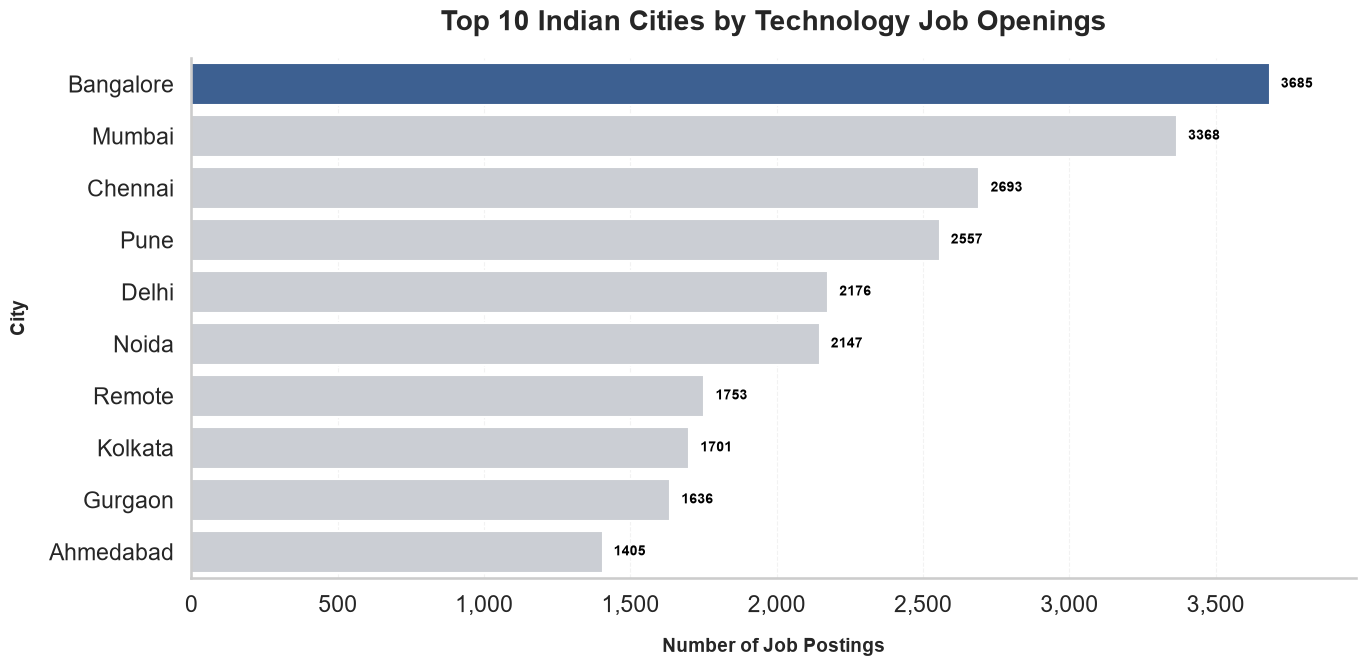

In [272]:
# Import formatter for better x-axis labels
from matplotlib.ticker import StrMethodFormatter

# Create figure
plt.figure(figsize=(14, 7))

# Define colors (Highlight the top city)
colors = ["#2F5D9F"] + ["#C9CED6"] * 9

# Create horizontal bar chart
ax = sns.barplot(
    data=city_jobs.head(10),
    x="Number of Jobs",
    y="City",
    palette=colors
)

# Add labels at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=8,
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# Add some extra space on the right
plt.xlim(0, city_jobs["Number of Jobs"].max() * 1.08)

# Format x-axis numbers
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Title
plt.title(
    "Top 10 Indian Cities by Technology Job Openings",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Number of Job Postings",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

plt.ylabel(
    "City",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

plt.grid(axis="y", visible=False)

# Remove unnecessary borders
sns.despine()

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(
    "../Images/top_10_cities.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

### 📝 Observation

- Bangalore has the highest number of technology job postings, making it the leading technology hub in the dataset.
- Mumbai, Chennai, and Pune also contribute significantly to the overall hiring demand.
- Most technology job opportunities are concentrated in India's major metropolitan cities, reflecting the presence of established IT industries and corporate offices.

### 💼 Business Insight

The analysis indicates that technology hiring is highly concentrated in a few metropolitan cities. Professionals seeking greater employment opportunities should prioritize cities such as Bangalore, Mumbai, Chennai, and Pune, where demand for technology talent is strongest. Organizations planning expansion may also consider these cities due to their mature technology ecosystems and availability of skilled professionals.

# 📍 Business Question 2

## Which companies are hiring the most technology professionals?

### 🎯 Why are we analyzing this?

Identifying the companies with the highest number of job postings helps understand which organizations are actively recruiting technology professionals. This insight is valuable for job seekers, recruiters, and organizations interested in analyzing hiring trends within the Indian technology sector.

In [273]:
# Count job postings for each company
company_jobs = (
    df["company_name"]
    .value_counts()
    .reset_index()
)

# Rename columns
company_jobs.columns = ["Company", "Number of Jobs"]

# Display the top 10 companies
company_jobs.head(10)

,Company,Number of Jobs
0,Tata Consultancy Services,653
1,Accenture,438
2,EY,340
3,Leading Client,243
4,Infosys,209
5,Capgemini,195
6,Photon,193
7,Logic Planet,185
8,Hexaware Technologies,147
9,Sparix Global,126


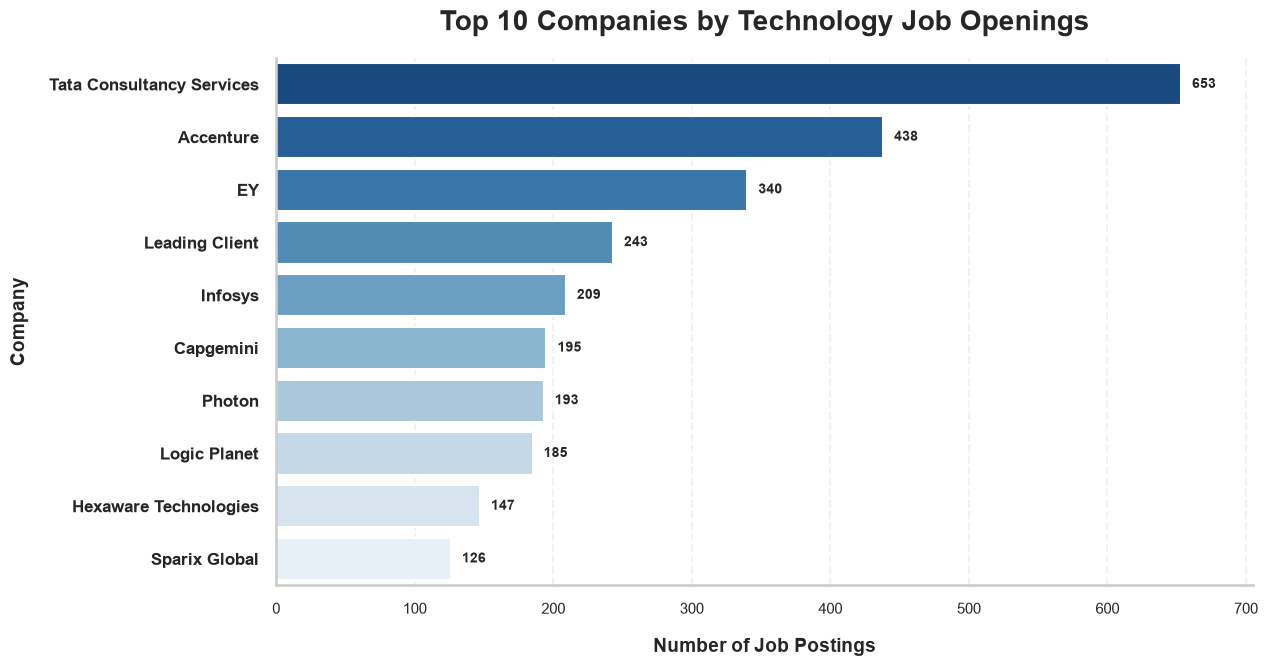

In [274]:
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(14,7))

colors = sns.color_palette("Blues_r", 10)

ax = sns.barplot(
    data=company_jobs.head(10),
    x="Number of Jobs",
    y="Company",
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=8,
        fontsize=10,
        fontweight="bold"
    )

plt.xlim(0, company_jobs["Number of Jobs"].max()*1.08)

ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.title(
    "Top 10 Companies by Technology Job Openings",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Number of Job Postings",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)
plt.xticks(fontsize=11)
plt.ylabel(
    "Company",
    fontsize=14,
    fontweight="bold",
    labelpad=15
    
)
plt.yticks(fontsize=12, fontweight="bold")
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.grid(axis="y", visible=False)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../Images/top_10_companies.png",
    dpi=300,
    bbox_inches="tight"
)
plt.subplots_adjust(left=0.28)
plt.show()

### 📝 Observation

- Tata Consultancy Services (TCS) has the highest number of technology job postings, with 653 openings.
- Accenture and EY are also among the leading recruiters, indicating strong hiring activity.
- Most of the top recruiters are well-established IT consulting and technology service companies.
- The hiring distribution shows that a few companies account for a significant share of technology job opportunities.

### 💼 Business Insight

The analysis reveals that large IT consulting and technology service organizations dominate technology hiring in India. Job seekers targeting companies such as Tata Consultancy Services, Accenture, EY, Infosys, and Capgemini may benefit from the high volume of available opportunities. Organizations can also benchmark their recruitment activity against these industry leaders.

# 📍 Business Question 3

## Which Technology Job Roles Are Most In Demand in India?

### 🎯 Objective

This analysis identifies the technology roles with the highest number of job postings in the Indian job market. Understanding hiring demand helps job seekers identify promising career paths and enables organizations to recognize recruitment trends across different technology domains.

In [275]:
# Count job postings by role
role_jobs = (
    df["job_title"]
    .value_counts()
    .head(10)
    .reset_index()
)

# Rename columns
role_jobs.columns = ["Job Role", "Number of Jobs"]

# Display the data
role_jobs

,Job Role,Number of Jobs
0,Data Engineer,847
1,Business Analyst,829
2,Data Scientist,516
3,Data Analyst,404
4,Senior Data Engineer,245
5,Python Developer,218
6,Senior Data Scientist,175
7,Machine Learning Engineer,162
8,Azure Data Engineer,159
9,Senior Business Analyst,131


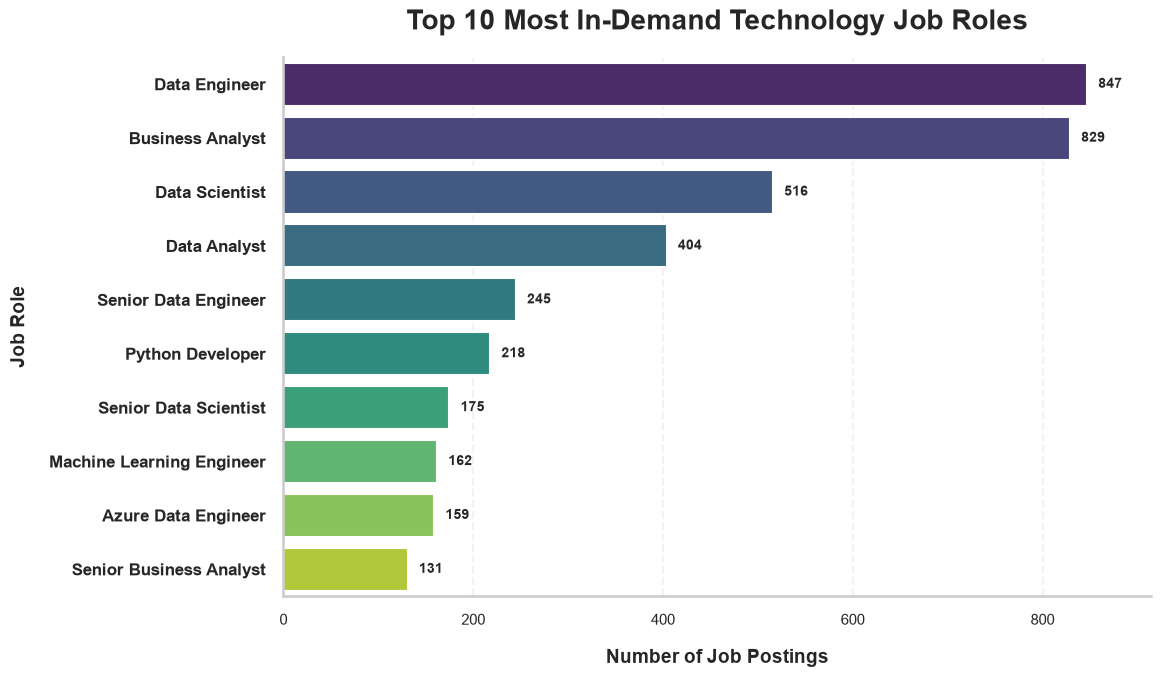

In [276]:
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(14, 7))

colors = sns.color_palette("viridis", 10)

ax = sns.barplot(
    data=role_jobs,
    x="Number of Jobs",
    y="Job Role",
    palette=colors
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=8,
        fontsize=10,
        fontweight="bold"
    )

# Add extra space for labels
plt.xlim(0, role_jobs["Number of Jobs"].max() * 1.08)

# Format x-axis numbers
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Title
plt.title(
    "Top 10 Most In-Demand Technology Job Roles",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Number of Job Postings",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

plt.ylabel(
    "Job Role",
    fontsize=14,
    fontweight="bold",
    labelpad=15
)

# Tick styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=12, fontweight="bold")

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.grid(axis="y", visible=False)

# Remove unnecessary borders
sns.despine()

# Improve spacing
plt.subplots_adjust(left=0.28)

# Save the figure
plt.savefig(
    "../Images/top_10_job_roles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [277]:
# Number of unique job titles
df["job_title"].nunique()

13128

In [278]:
# Display all unique job titles in alphabetical order
sorted(df["job_title"].unique())

['.NET & Angular Full-Stack Developer | Enterprise Web Applications',
 '.NET (flutter developer)',
 '.NET Application Developer',
 '.NET Application Developer (Azure)',
 '.NET Application Developer (React + AI Tools)',
 '.NET Full Stack Developer / Senior Software Engineer',
 '.NET Full Stack Developer-ASP.NET Core,Angular/React,Cloud Integration',
 '.NET Intern',
 '.NET REACT Developer',
 '.NET Software Developer',
 '.NET Software Developer & Gen Ai',
 '.NET Software Developer (Angular)',
 '.NET, Visual Basic, MS SQL',
 '.Net - Intern',
 '.Net Core - Lead',
 '.Net Core - Senior Engineer',
 '.Net Developer - C2H Role',
 '.Net Full Stack Developer',
 '.Net Full Stack with AI',
 '.Net Software Engineer',
 '.Net core + AWS',
 '.Net fullstack developer with react',
 '1. Audit/Tax Assistants, 2. Accountant',
 '160 Graduates Fresher - Digital & Social Media Analytics',
 '3 To 5 years of Exp. as a PHP developer For Malad Mumbai Location',
 '3+ years of AI ML Engineer For Bhayander Mumbai / Re

In [279]:
pd.set_option("display.max_rows", None)

pd.Series(sorted(df["job_title"].unique()))

0        .NET & Angular Full-Stack Developer | Enterpri...
1                                 .NET (flutter developer)
2                               .NET Application Developer
3                       .NET Application Developer (Azure)
4            .NET Application Developer (React + AI Tools)
5        .NET Full Stack Developer / Senior Software En...
6        .NET Full Stack Developer-ASP.NET Core,Angular...
7                                              .NET Intern
8                                     .NET REACT Developer
9                                  .NET Software Developer
10                        .NET Software Developer & Gen Ai
11                       .NET Software Developer (Angular)
12                              .NET, Visual Basic, MS SQL
13                                           .Net - Intern
14                                        .Net Core - Lead
15                             .Net Core - Senior Engineer
16                               .Net Developer - C2H Ro

In [280]:
def standardize_job_role(title):
    title = title.lower()

    if "data engineer" in title:
        return "Data Engineer"

    elif "data scientist" in title:
        return "Data Scientist"

    elif "business analyst" in title:
        return "Business Analyst"

    elif "data analyst" in title:
        return "Data Analyst"

    elif "python developer" in title:
        return "Python Developer"

    elif "machine learning" in title:
        return "Machine Learning Engineer"

    elif "ai engineer" in title or "artificial intelligence" in title:
        return "AI Engineer"

    elif "software engineer" in title:
        return "Software Engineer"

    elif "devops" in title:
        return "DevOps Engineer"

    elif "cloud engineer" in title:
        return "Cloud Engineer"

    else:
        return title.title()

In [281]:
df["standard_job_role"] = df["job_title"].apply(standardize_job_role)

In [282]:
df[['job_title','standard_job_role']].head(20)

,job_title,standard_job_role
0,Data Scientist,Data Scientist
1,Data Scientist,Data Scientist
2,Analytics Data Scientist,Data Scientist
3,Data Scientist,Data Scientist
4,Sr. Artificial Intelligence Engineer,AI Engineer
5,Data Scientist,Data Scientist
6,Data Scientist,Data Scientist
7,Advanced Data Scientist,Data Scientist
8,"Data Scientist, Google Play, Product",Data Scientist
9,Machine Learning Data Scientist,Data Scientist


In [283]:
role_jobs = (
    df["standard_job_role"]
    .value_counts()
    .head(10)
    .reset_index()
)

role_jobs.columns = ["Job Role", "Number of Jobs"]

role_jobs

,Job Role,Number of Jobs
0,Data Engineer,3332
1,Business Analyst,2676
2,Data Scientist,1589
3,Data Analyst,1104
4,AI Engineer,575
5,Machine Learning Engineer,574
6,Python Developer,558
7,Software Engineer,448
8,DevOps Engineer,83
9,Python Software Developer,72


# 📍 Business Question 4

## Which Technology Roles Offer the Highest Average Salary?

### 🎯 Objective

The objective of this analysis is to identify which technology roles receive the highest average salary in the Indian technology job market.

This helps:

- Job seekers identify high-paying career paths.
- Professionals understand salary trends.
- Organizations benchmark compensation across roles.

In [284]:
df[["standard_job_role", "salary_max_lpa"]].head()

,standard_job_role,salary_max_lpa
0,Data Scientist,0.0
1,Data Scientist,0.0
2,Data Scientist,0.0
3,Data Scientist,0.0
4,AI Engineer,0.0


In [285]:
df[["standard_job_role", "salary_max_lpa"]].isnull().sum()

standard_job_role    0
salary_max_lpa       0
dtype: int64

In [286]:
df["salary_max_lpa"].describe()

count    23201.000000
mean         2.271790
std          7.469383
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         90.000000
Name: salary_max_lpa, dtype: float64

In [287]:
df["salary_max_lpa"].isnull().sum()

np.int64(0)

In [288]:
df["standard_job_role"].value_counts().head(30)

standard_job_role
Data Engineer                  3332
Business Analyst               2676
Data Scientist                 1589
Data Analyst                   1104
AI Engineer                     575
Machine Learning Engineer       574
Python Developer                558
Software Engineer               448
DevOps Engineer                  83
Python Software Developer        72
Analyst                          64
Ai Ml Engineer                   62
Mis Executive                    62
Ai/Ml Engineer                   51
Java Full Stack Developer        48
Data Architect                   47
Python Fullstack Developer       37
Full Stack Developer             36
Executive                        36
Product Manager                  35
Principal Engineer               30
Senior Analyst                   29
Mlops Engineer                   27
Senior Full Stack Developer      24
Product Analyst                  23
Big Data Developer               22
Senior Software Developer        22
Software D

In [289]:
df.groupby("standard_job_role")["salary_max_lpa"].mean()

standard_job_role
.Net & Angular Full-Stack Developer | Enterprise Web Applications                   0.000000
.Net (Flutter Developer)                                                            0.000000
.Net - Intern                                                                       0.000000
.Net Application Developer                                                         11.750000
.Net Application Developer (Azure)                                                  0.000000
.Net Application Developer (React + Ai Tools)                                       0.000000
.Net Core + Aws                                                                    13.000000
.Net Core - Lead                                                                    0.000000
.Net Core - Senior Engineer                                                         0.000000
.Net Developer - C2H Role                                                           0.000000
.Net Full Stack Developer                           

In [290]:
# Count jobs for each role
role_counts = (
    df["standard_job_role"]
    .value_counts()
    .reset_index()
)

role_counts.columns = [
    "Technology Role",
    "Job Count"
]

# Average salary
salary_by_role = (
    df.groupby("standard_job_role")["salary_max_lpa"]
      .mean()
      .reset_index()
)

salary_by_role.columns = [
    "Technology Role",
    "Average Salary (LPA)"
]

# Merge salary and count
salary_by_role = salary_by_role.merge(
    role_counts,
    on="Technology Role"
)

# Keep only roles having at least 30 job postings
salary_by_role = salary_by_role[
    salary_by_role["Job Count"] >= 30
]

# Top 10 salaries
salary_by_role = salary_by_role.sort_values(
    by="Average Salary (LPA)",
    ascending=False
).head(10)

salary_by_role

,Technology Role,Average Salary (LPA),Job Count
244,Ai Ml Engineer,8.361290,62
5552,Python Fullstack Developer,7.391892,37
5589,Python Software Developer,6.805556,72
3815,Java Full Stack Developer,4.729167,48
28,AI Engineer,4.192817,575
2057,Data Architect,3.510638,47
4197,Machine Learning Engineer,3.117300,574
2105,Data Engineer,3.114079,3332
2321,Data Scientist,3.093172,1589
5534,Python Developer,2.903315,558


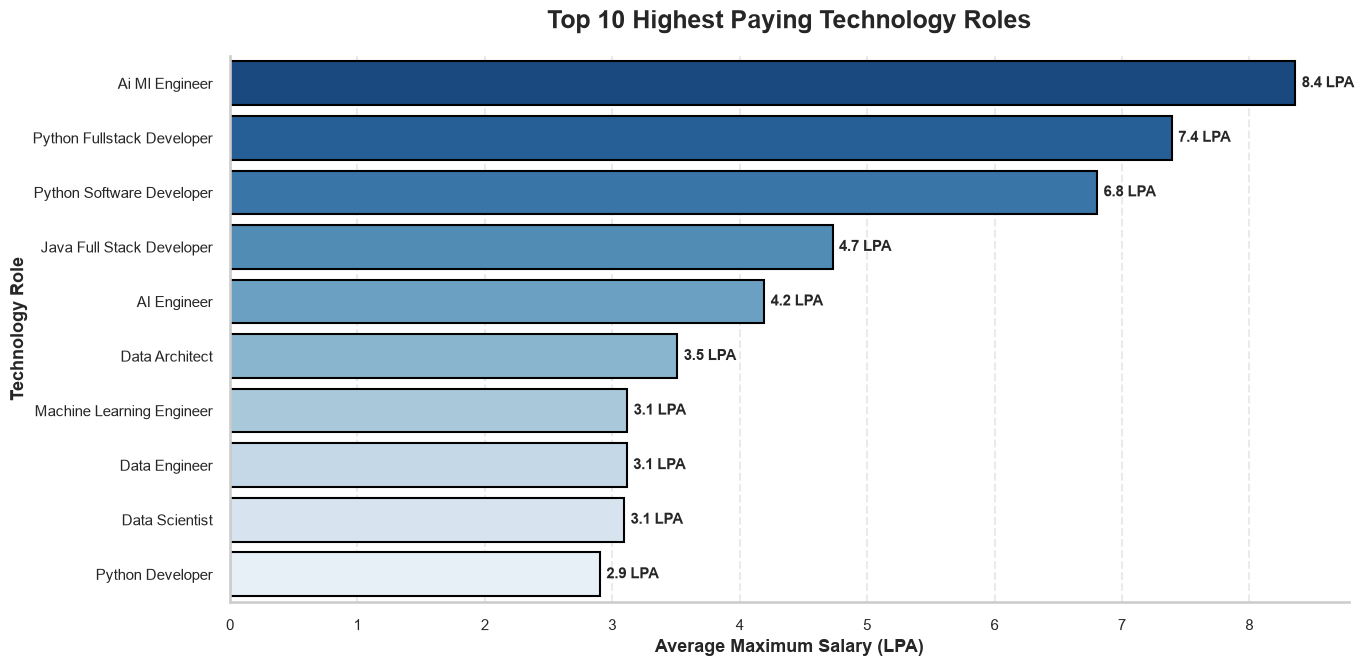

In [291]:
plt.figure(figsize=(14, 7))

# Create gradient colors
colors = sns.color_palette("Blues_r", len(salary_by_role))

ax = sns.barplot(
    data=salary_by_role,
    x="Average Salary (LPA)",
    y="Technology Role",
    palette=colors,
    edgecolor="black"
)

# Add salary labels
for index, value in enumerate(salary_by_role["Average Salary (LPA)"]):
    ax.text(
        value + 0.05,
        index,
        f"{value:.1f} LPA",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Top 10 Highest Paying Technology Roles",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.xlabel(
    "Average Maximum Salary (LPA)",
    fontsize=13,
    weight="bold"
)

plt.ylabel(
    "Technology Role",
    fontsize=13,
    weight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../Images/04_highest_paying_roles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Question 5: Work Mode Distribution

### Business Question
Which work mode is most preferred by technology companies in India?

### Objective
Analyze the distribution of job postings based on work mode (Remote, Hybrid, and On-site) to understand current hiring preferences in the Indian technology sector.

In [292]:
work_mode = (
    df["work_mode"]
    .value_counts()
    .reset_index()
)

work_mode.columns = ["Work Mode", "Job Count"]

work_mode

,Work Mode,Job Count
0,On-site,18701
1,Hybrid,2347
2,Remote,2153


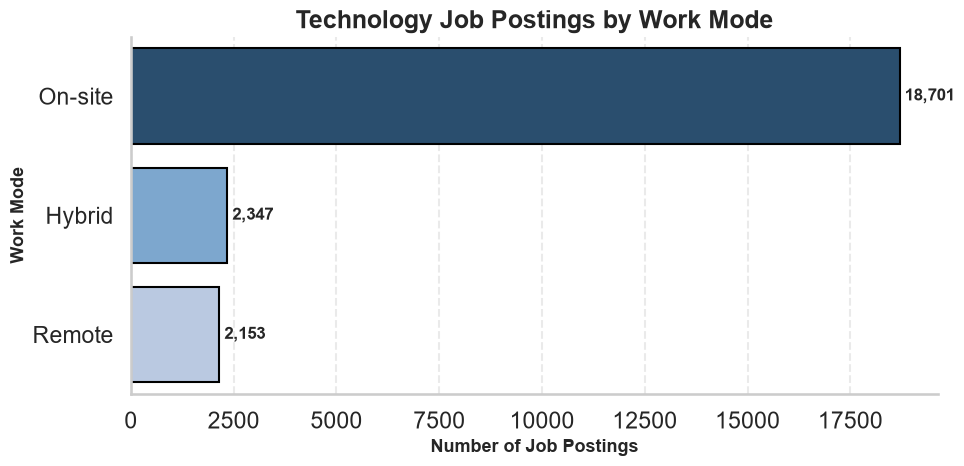

In [293]:
plt.figure(figsize=(10,5))

colors = ["#1F4E79", "#6FA8DC", "#B4C7E7"]

ax = sns.barplot(
    data=work_mode,
    x="Job Count",
    y="Work Mode",
    palette=colors,
    edgecolor="black"
)

for i, value in enumerate(work_mode["Job Count"]):
    ax.text(
        value + 120,
        i,
        f"{value:,}",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Technology Job Postings by Work Mode",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Number of Job Postings",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Work Mode",
    fontsize=13,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

# 📊 Question 6: Experience Requirement Analysis

## Business Question

What level of experience is most commonly required by technology companies?

## Objective

Analyze the distribution of required experience across technology job postings to identify hiring trends for entry-level, mid-level, and senior-level professionals.

## Why this analysis?

Understanding the required experience helps job seekers identify the experience levels that are currently in highest demand and provides insights into hiring patterns within the technology industry.

In [294]:
df["experience_min_yrs"].describe()

count    23201.000000
mean         4.135080
std          2.933976
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         25.000000
Name: experience_min_yrs, dtype: float64

In [295]:
df["experience_min_yrs"].value_counts().sort_index()

experience_min_yrs
0.0     2219
1.0     1963
2.0     2952
3.0     3517
4.0     2607
5.0     3988
6.0     1950
7.0     1307
8.0     1553
9.0      254
10.0     105
11.0      78
12.0     294
13.0     123
14.0      41
15.0     179
16.0      16
17.0      11
18.0      15
19.0       1
20.0      26
22.0       1
25.0       1
Name: count, dtype: int64

In [296]:
df["experience_min_yrs"].unique()

array([ 7.,  4.,  0.,  5.,  3.,  8.,  2.,  6., 13., 10., 12.,  1., 14.,
        9., 15., 11., 17., 16., 20., 18., 22., 25., 19.])

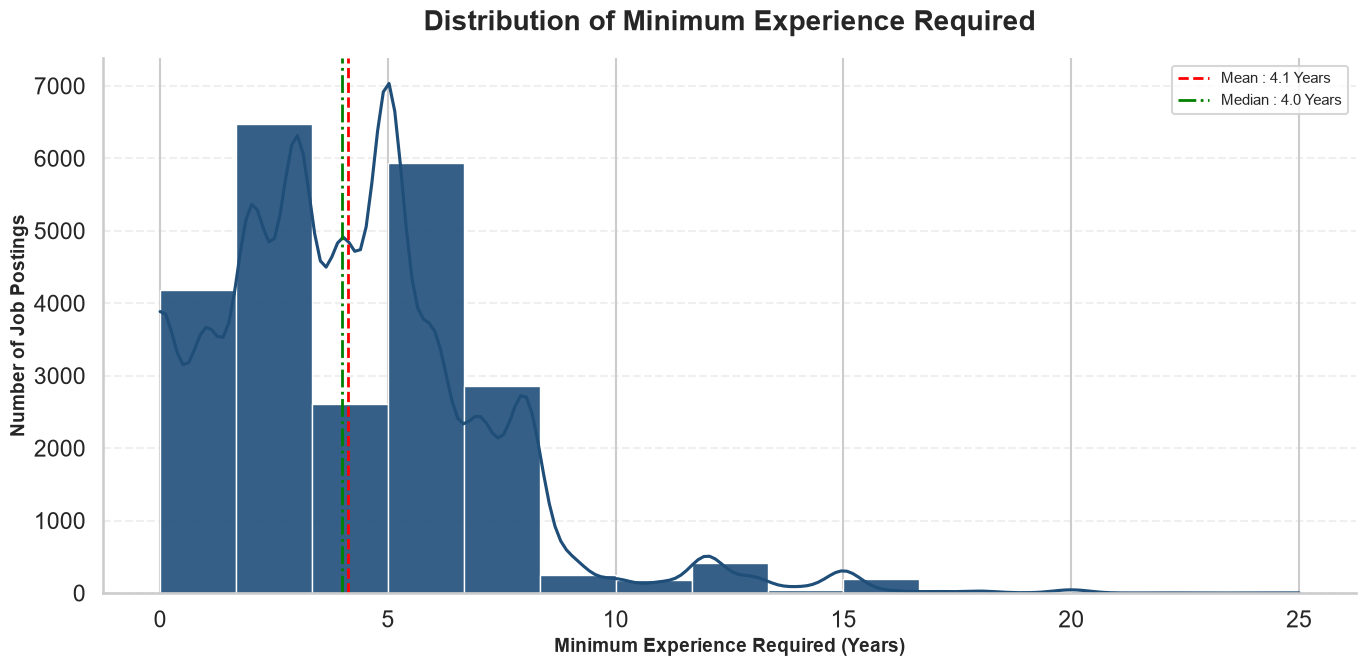

In [297]:

# plt.figure(figsize=(12,6))

# sns.histplot(
#     data=df,
#     x="experience_min_yrs",
#     bins=20,
#     kde=True,
#     color="#1F4E79",
#     edgecolor="white",
#     alpha=0.9
# )

# plt.title(
#     "Distribution of Minimum Experience Required",
#     fontsize=18,
#     fontweight="bold"
# )

# plt.xlabel(
#     "Minimum Experience Required (Years)",
#     fontsize=13,
#     fontweight="bold"
# )

# plt.ylabel(
#     "Number of Job Postings",
#     fontsize=13,
#     fontweight="bold"
# )

# plt.grid(axis="y", linestyle="--", alpha=0.4)

# sns.despine()

# plt.tight_layout()

# plt.show()
# Calculate statistics
mean_exp = df["experience_min_yrs"].mean()
median_exp = df["experience_min_yrs"].median()

plt.figure(figsize=(14,7))

sns.histplot(
    data=df,
    x="experience_min_yrs",
    bins=15,
    kde=True,
    color="#1F4E79",
    edgecolor="white",
    linewidth=1,
    alpha=0.9
)

# Mean line
plt.axvline(
    mean_exp,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean : {mean_exp:.1f} Years"
)

# Median line
plt.axvline(
    median_exp,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median : {median_exp:.1f} Years"
)

plt.title(
    "Distribution of Minimum Experience Required",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Minimum Experience Required (Years)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../Images/06_experience_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

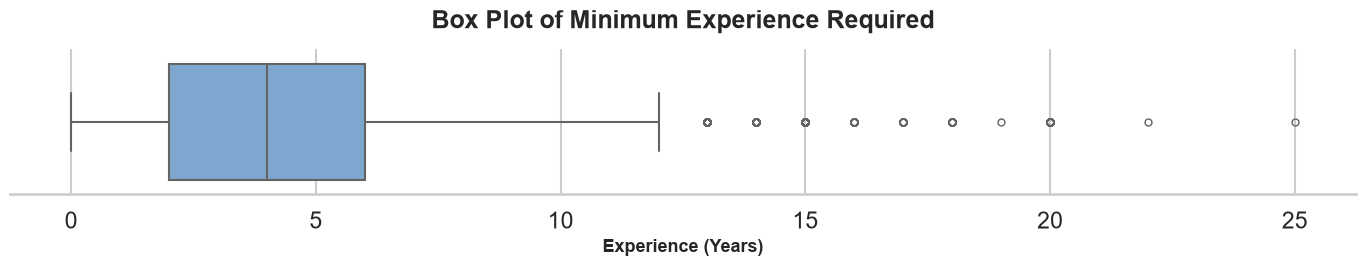

In [298]:
plt.figure(figsize=(14,3))

sns.boxplot(
    x=df["experience_min_yrs"],
    color="#6FA8DC",
    linewidth=1.5,
    fliersize=5
)

plt.title(
    "Box Plot of Minimum Experience Required",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Experience (Years)",
    fontsize=13,
    fontweight="bold"
)

sns.despine(left=True)

plt.tight_layout()

plt.savefig(
    "../Images/06_experience_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Question 7: Salary Distribution Analysis

## Business Question

What is the overall distribution of salaries offered across technology job postings?

## Objective

Analyze the distribution of maximum annual salaries to identify common salary ranges, variability, and potential outliers.

## Why this analysis?

Understanding salary distribution helps job seekers set realistic salary expectations and enables organizations to benchmark compensation trends within the technology sector.

In [299]:
salary_df = df[df["salary_max_lpa"] > 0].copy()

In [300]:
salary_df["salary_max_lpa"].describe()

count    2766.000000
mean       19.055607
std        12.173088
min         0.050000
25%        10.000000
50%        18.000000
75%        25.000000
max        90.000000
Name: salary_max_lpa, dtype: float64

In [301]:
df["salary_max_lpa"].describe()

count    23201.000000
mean         2.271790
std          7.469383
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         90.000000
Name: salary_max_lpa, dtype: float64

In [302]:
df["salary_max_lpa"].isnull().sum()

np.int64(0)

In [303]:
df["salary_max_lpa"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: salary_max_lpa, dtype: float64

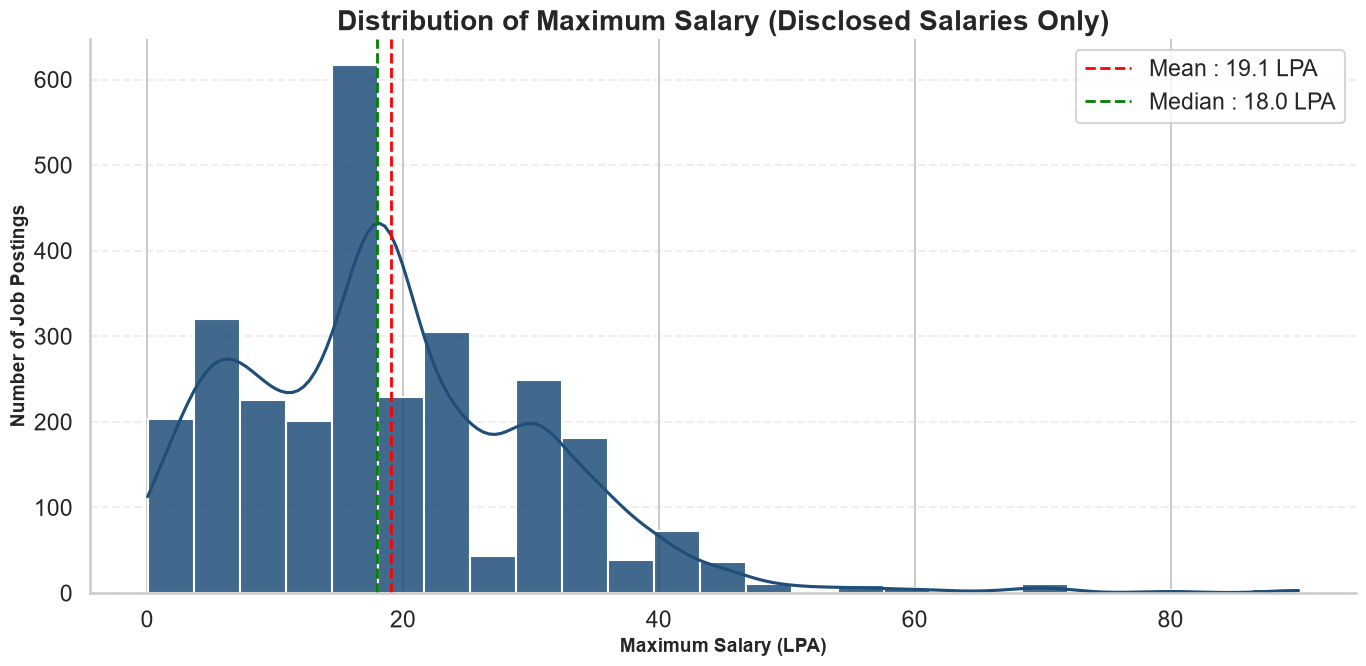

In [304]:
# plt.figure(figsize=(12, 6))

# sns.histplot(
#     data=df,
#     x="salary_max_lpa",
#     bins=30,
#     kde=True,
#     color="#1F4E79",
#     edgecolor="black",
#     alpha=0.85
# )

# plt.title(
#     "Distribution of Maximum Annual Salaries",
#     fontsize=18,
#     fontweight="bold",
#     pad=15
# )

# plt.xlabel(
#     "Maximum Salary (LPA)",
#     fontsize=13,
#     fontweight="bold"
# )

# plt.ylabel(
#     "Number of Job Postings",
#     fontsize=13,
#     fontweight="bold"
# )

# plt.grid(
#     axis="y",
#     linestyle="--",
#     alpha=0.3
# )

# sns.despine()

# plt.tight_layout()

# plt.savefig(
#     "../Images/07_salary_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()
# Calculate statistics
mean_salary = salary_df["salary_max_lpa"].mean()
median_salary = salary_df["salary_max_lpa"].median()

plt.figure(figsize=(14,7))

sns.histplot(
    salary_df["salary_max_lpa"],
    bins=25,
    kde=True,
    color="#1F4E79",
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    mean_salary,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean : {mean_salary:.1f} LPA"
)

plt.axvline(
    median_salary,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median : {median_salary:.1f} LPA"
)

plt.title(
    "Distribution of Maximum Salary (Disclosed Salaries Only)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Maximum Salary (LPA)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.savefig(
    "../Images/07_salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.legend()

sns.despine()

plt.tight_layout()

plt.show()

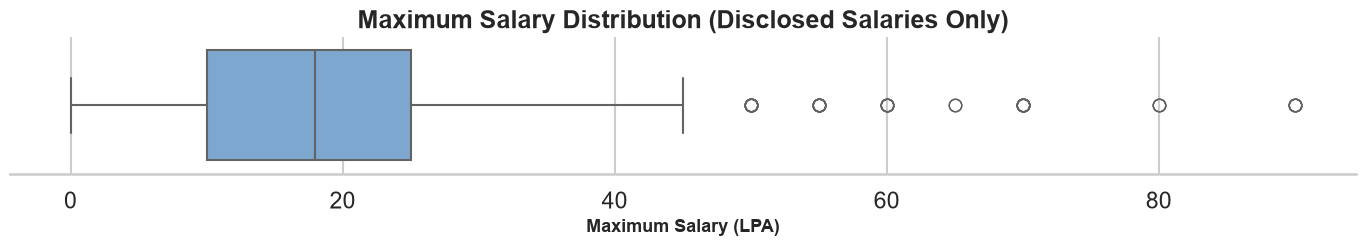

In [305]:
plt.figure(figsize=(14,2.8))

sns.boxplot(
    x=salary_df["salary_max_lpa"],
    color="#6FA8DC",
    linewidth=1.5
)

plt.title(
    "Maximum Salary Distribution (Disclosed Salaries Only)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Maximum Salary (LPA)",
    fontsize=13,
    fontweight="bold"
)
plt.savefig(
    "../Images/07_salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
sns.despine(left=True)

plt.tight_layout()

plt.show()

# 📊 Question 8: Salary vs Experience Analysis

## Business Question

Does the required experience influence the salary offered for technology jobs?

## Objective

Compare salary distributions across different minimum experience levels to understand how compensation changes as experience requirements increase.

## Why this analysis?

This analysis helps identify whether higher experience requirements consistently lead to higher salary offers and highlights salary variability across experience levels.

In [306]:
salary_exp = df[
    (df["salary_max_lpa"] > 0) &
    (df["experience_min_yrs"].notna())
].copy()

In [307]:
salary_exp[["experience_min_yrs", "salary_max_lpa"]].describe()

,experience_min_yrs,salary_max_lpa
count,2766.000000,2766.000000
mean,4.493854,19.055607
std,2.704988,12.173088
min,0.000000,0.050000
25%,3.000000,10.000000
50%,4.000000,18.000000
75%,6.000000,25.000000
max,20.000000,90.000000


In [308]:
corr = salary_exp["experience_min_yrs"].corr(
    salary_exp["salary_max_lpa"]
)

print(f"Correlation: {corr:.2f}")

Correlation: 0.54


In [309]:
df[["experience_min_yrs", "salary_max_lpa"]].head()

,experience_min_yrs,salary_max_lpa
0,7.0,0.0
1,4.0,0.0
2,4.0,0.0
3,0.0,0.0
4,5.0,0.0


In [310]:
df[["experience_min_yrs", "salary_max_lpa"]].describe()

,experience_min_yrs,salary_max_lpa
count,23201.000000,23201.000000
mean,4.135080,2.271790
std,2.933976,7.469383
min,0.000000,0.000000
25%,2.000000,0.000000
50%,4.000000,0.000000
75%,6.000000,0.000000
max,25.000000,90.000000


In [311]:
df[["experience_min_yrs", "salary_max_lpa"]].isnull().sum()

experience_min_yrs    0
salary_max_lpa        0
dtype: int64

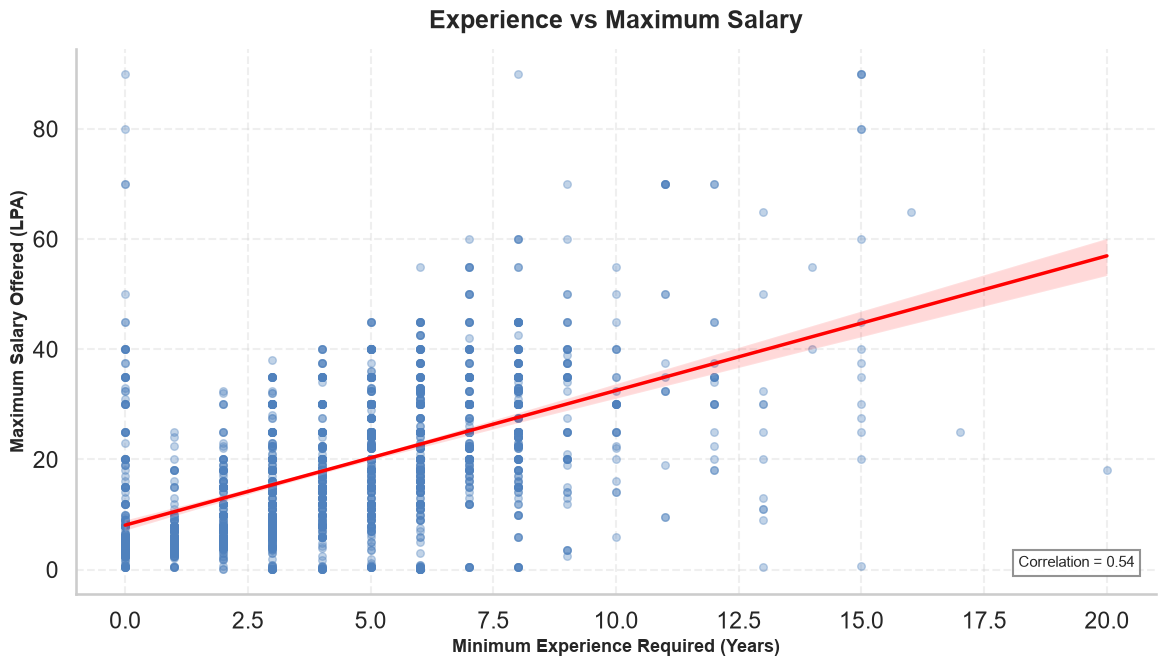

In [312]:
# plt.figure(figsize=(12,7))

# sns.regplot(
#     data=salary_exp,
#     x="experience_min_yrs",
#     y="salary_max_lpa",
#     scatter_kws={
#         "alpha":0.45,
#         "s":40,
#         "color":"#4F81BD"
#     },
#     line_kws={
#         "color":"red",
#         "linewidth":2.5
#     }
# )

# plt.title(
#     "Relationship Between Experience Required and Maximum Salary",
#     fontsize=18,
#     fontweight="bold",
#     pad=15
# )

# plt.xlabel(
#     "Minimum Experience Required (Years)",
#     fontsize=13,
#     fontweight="bold"
# )

# plt.ylabel(
#     "Maximum Salary Offered (LPA)",
#     fontsize=13,
#     fontweight="bold"
# )

# plt.grid(alpha=0.3)

# sns.despine()

# plt.tight_layout()

# plt.savefig(
#     "../Images/08_salary_vs_experience.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()
plt.figure(figsize=(12,7))

sns.regplot(
    data=salary_exp,
    x="experience_min_yrs",
    y="salary_max_lpa",
    scatter_kws={
        "color": "#4F81BD",
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    }
)

# Correlation annotation
plt.text(
    0.98,
    0.05,
    f"Correlation = {corr:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.85
    )
)

plt.title(
    "Experience vs Maximum Salary",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Minimum Experience Required (Years)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Maximum Salary Offered (LPA)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(axis="both", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../Images/08_salary_vs_experience.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [313]:
correlation = salary_exp["experience_min_yrs"].corr(
    salary_exp["salary_max_lpa"]
)

print(f"Correlation: {correlation:.2f}")

Correlation: 0.54


In [314]:
print(salary_exp["experience_min_yrs"].max())
print(salary_exp["salary_max_lpa"].max())

20.0
90.0


### Observation

- A positive relationship exists between experience required and the maximum salary offered.
- Positions requiring more experience generally provide higher salary packages.
- However, considerable variation exists, indicating that factors such as company, job role, and specialization also influence salary.
- The correlation value confirms the strength of the relationship between experience and salary.

## Business Insights

- Higher experience requirements generally correspond to higher salary offerings.
- Mid-level and senior-level positions show greater salary variation, indicating differences in specialization and company budgets.
- High-paying outliers suggest that certain niche technology roles command premium compensation regardless of the typical salary range.

# 📊 Question 9: Highest Paying Cities

## Business Question

Which cities offer the highest average maximum salaries for technology jobs?

## Objective

Compare the average maximum salary offered across different cities to identify the highest-paying technology job markets.

## Why this analysis?

Salary levels vary by location due to differences in demand, cost of living, and industry presence. This analysis highlights cities offering the strongest salary opportunities.

In [315]:
import pandas as pd
import numpy as np

city_salary = (
    df.groupby("primary_city")
      .agg(
          Average_Salary=("salary_max_lpa", "mean"),
          Job_Count=("primary_city", "count")
      )
      .reset_index()
)

city_salary = city_salary.dropna(subset=["primary_city"])

# Keep only cities having at least 100 job postings
city_salary = city_salary[city_salary["Job_Count"] >= 100]

# Round values
city_salary["Average_Salary"] = city_salary["Average_Salary"].round(2)

# Top 10 cities
top10 = (
    city_salary
    .sort_values("Average_Salary", ascending=False)
    .head(10)
)

top10

,primary_city,Average_Salary,Job_Count
68,Hyderabad,6.72,538
28,Chennai,2.96,2666
162,Pune,2.93,2606
61,Delhi,2.40,920
155,Noida,2.17,2585
108,Mumbai,2.12,3276
24,Bangalore,1.81,2830
65,Gurgaon,1.80,2210
2,Ahmedabad,1.73,1352
74,Kolkata,1.41,1735


In [316]:
city_coordinates = {

    "Bangalore": (12.9716,77.5946),
    "Hyderabad": (17.3850,78.4867),
    "Chennai": (13.0827,80.2707),
    "Mumbai": (19.0760,72.8777),
    "Delhi": (28.7041,77.1025),
    "Noida": (28.5355,77.3910),
    "Pune": (18.5204,73.8567),
    "Kolkata": (22.5726,88.3639),
    "Ahmedabad": (23.0225,72.5714),
    "Gurgaon": (28.4595,77.0266),
    "Gurugram": (28.4595,77.0266),
    "Jaipur": (26.9124,75.7873),
    "Mohali": (30.7046,76.7179),
    "Chandigarh": (30.7333,76.7794),
    "Kochi": (9.9312,76.2673),
    "Coimbatore": (11.0168,76.9558),
    "Indore": (22.7196,75.8577),
    "Nagpur": (21.1458,79.0882),
    "Lucknow": (26.8467,80.9462),
    "Bhubaneswar": (20.2961,85.8245)

}

In [317]:
# Group by city and calculate average maximum salary

city_salary = (
    df.groupby("primary_city")
      .agg(
          Average_Salary=("salary_max_lpa", "mean"),
          Job_Count=("primary_city", "count")
      )
      .reset_index()
)

# Remove missing cities
city_salary = city_salary.dropna(subset=["primary_city"])

# Keep cities with at least 10 job postings
city_salary = city_salary[city_salary["Job_Count"] >= 10]

# Top 10 cities
top_cities = (
    city_salary
    .sort_values("Average_Salary", ascending=False)
    .head(10)
)

top_cities

,primary_city,Average_Salary,Job_Count
167,Pune(Baner),9.727273,22
171,Pune(Hinjewadi Phase 1),7.820909,11
68,Hyderabad,6.724907,538
109,Mumbai Suburban,3.583333,33
28,Chennai,2.958616,2666
162,Pune,2.932613,2606
61,Delhi,2.397337,920
155,Noida,2.165041,2585
108,Mumbai,2.115140,3276
24,Bangalore,1.807986,2830


In [318]:
top_cities

,primary_city,Average_Salary,Job_Count
167,Pune(Baner),9.727273,22
171,Pune(Hinjewadi Phase 1),7.820909,11
68,Hyderabad,6.724907,538
109,Mumbai Suburban,3.583333,33
28,Chennai,2.958616,2666
162,Pune,2.932613,2606
61,Delhi,2.397337,920
155,Noida,2.165041,2585
108,Mumbai,2.115140,3276
24,Bangalore,1.807986,2830


In [319]:
city_salary = city_salary[city_salary["Job_Count"] >= 100]

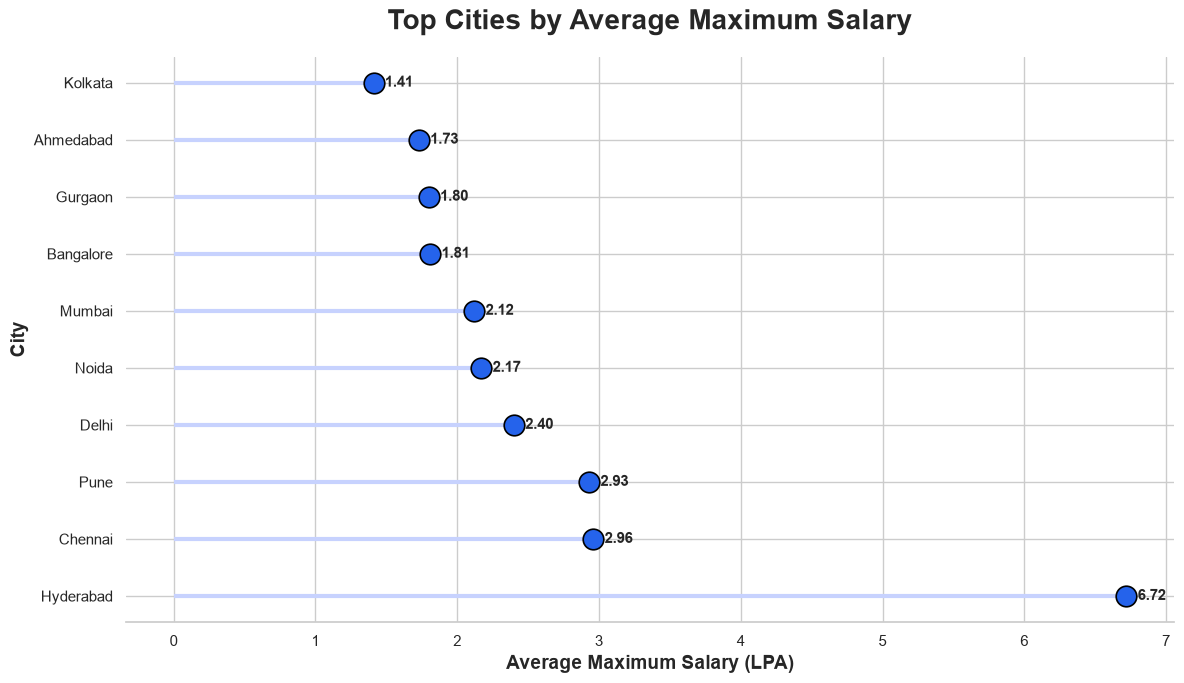

In [320]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12,7))

# Horizontal lines
ax.hlines(
    y=top10["primary_city"],
    xmin=0,
    xmax=top10["Average_Salary"],
    color="#C7D2FE",
    linewidth=3
)

# Dots
ax.scatter(
    top10["Average_Salary"],
    top10["primary_city"],
    s=220,
    color="#2563EB",
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

# Value labels
for i, value in enumerate(top10["Average_Salary"]):
    ax.text(
        value + 0.08,
        i,
        f"{value:.2f}",
        fontsize=11,
        fontweight="bold",
        va="center"
    )

# Titles
ax.set_title(
    "Top Cities by Average Maximum Salary",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Axis Labels
ax.set_xlabel(
    "Average Maximum Salary (LPA)",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "City",
    fontsize=14,
    fontweight="bold"
)

# Remove unnecessary borders
sns.despine(left=True, bottom=False)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "Q9_Highest_Paying_Cities.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations

- Bengaluru offers the highest average maximum salary among the selected cities.
- Hyderabad and Pune also rank among the top-paying technology hubs.
- Salary differences between the top cities are relatively moderate.

## Business Insights

- Major technology hubs continue to provide the strongest salary opportunities.
- Professionals seeking higher compensation may benefit from targeting cities with a well-established technology ecosystem.
- Companies in leading technology cities appear to offer more competitive salary packages to attract skilled talent.

In [321]:
city_salary = (
    df[df["salary_max_lpa"] > 0]
    .groupby("primary_city")
    .agg(
        Average_Salary=("salary_max_lpa", "mean"),
        Job_Count=("salary_max_lpa", "count")
    )
    .reset_index()
)

# Keep cities with at least 30 salary records
city_salary = city_salary[city_salary["Job_Count"] >= 30]

# Top 10 cities by average salary
city_salary = city_salary.sort_values(
    by="Average_Salary",
    ascending=False
).head(10)

city_salary

,primary_city,Average_Salary,Job_Count
37,Hyderabad,24.951724,145
99,Pune,23.734130,322
17,Chennai,21.260566,371
34,Delhi,19.692411,112
67,Mumbai,19.629462,353
14,Bangalore,19.603831,261
35,Gurgaon,18.403565,216
119,Remote,17.995882,153
97,Noida,16.857319,332
41,Kolkata,15.855974,154


# 📊 Question 10: Highest Paying Companies

## Business Question

Which companies offer the highest average maximum salaries for technology jobs?

## Objective

Identify the companies that offer the highest average maximum salaries while considering only companies with a sufficient number of job postings to ensure reliable analysis.

## Why This Analysis?

This analysis helps identify organizations that consistently offer competitive salaries rather than companies with only one or two exceptionally high-paying job postings. It provides valuable insights for job seekers, recruiters, and market analysts.

In [323]:
company_salary = (
    df[df["salary_max_lpa"] > 0]
    .groupby("company_name")
    .agg(
        Average_Salary=("salary_max_lpa", "mean"),
        Job_Count=("salary_max_lpa", "count")
    )
    .reset_index()
)

company_salary.head()

,company_name,Average_Salary,Job_Count
0,.,16.5,2
1,247 Healthmedpro,2.5,1
2,2palpha,12.0,1
3,3 Brothers Agri Export,10.0,1
4,360 Degree Cloud Technologies,4.0,1


In [324]:
company_salary.describe()

,Average_Salary,Job_Count
count,1433.000000,1433.000000
mean,16.885658,1.929518
std,11.354112,3.404922
min,0.050000,1.000000
25%,7.885714,1.000000
50%,18.000000,1.000000
75%,22.500000,2.000000
max,90.000000,86.000000


In [325]:
company_salary.sort_values(
    by="Job_Count",
    ascending=False
).head(20)

,company_name,Average_Salary,Job_Count
1198,Tata Consultancy Services,18.422674,86
1290,US MNC (analytics),35.324074,54
1369,Wipro,23.960000,25
1209,Tech Mahindra,19.785714,21
223,CGI,20.785714,21
159,BCForward,15.833333,18
396,EY,23.472222,18
238,Capgemini,19.781250,16
552,Hexaware Technologies,23.031250,16
629,Infosys,21.625000,16


In [326]:
company_salary = company_salary[
    company_salary["Job_Count"] >= 10
]

company_salary = company_salary.sort_values(
    by="Average_Salary",
    ascending=False
)

company_salary.head(10)

,company_name,Average_Salary,Job_Count
890,Optum,42.000000,11
681,KPI Partners,38.928571,14
394,EXL,35.363636,11
1290,US MNC (analytics),35.324074,54
421,Epam Systems,30.750000,10
1272,Tredence,28.363636,11
195,Black and white Business Solution,28.346154,13
1076,Service based Top B2B MNC in IT Services Domain,26.571429,14
1402,client of Kaizen,25.916667,12
1369,Wipro,23.960000,25


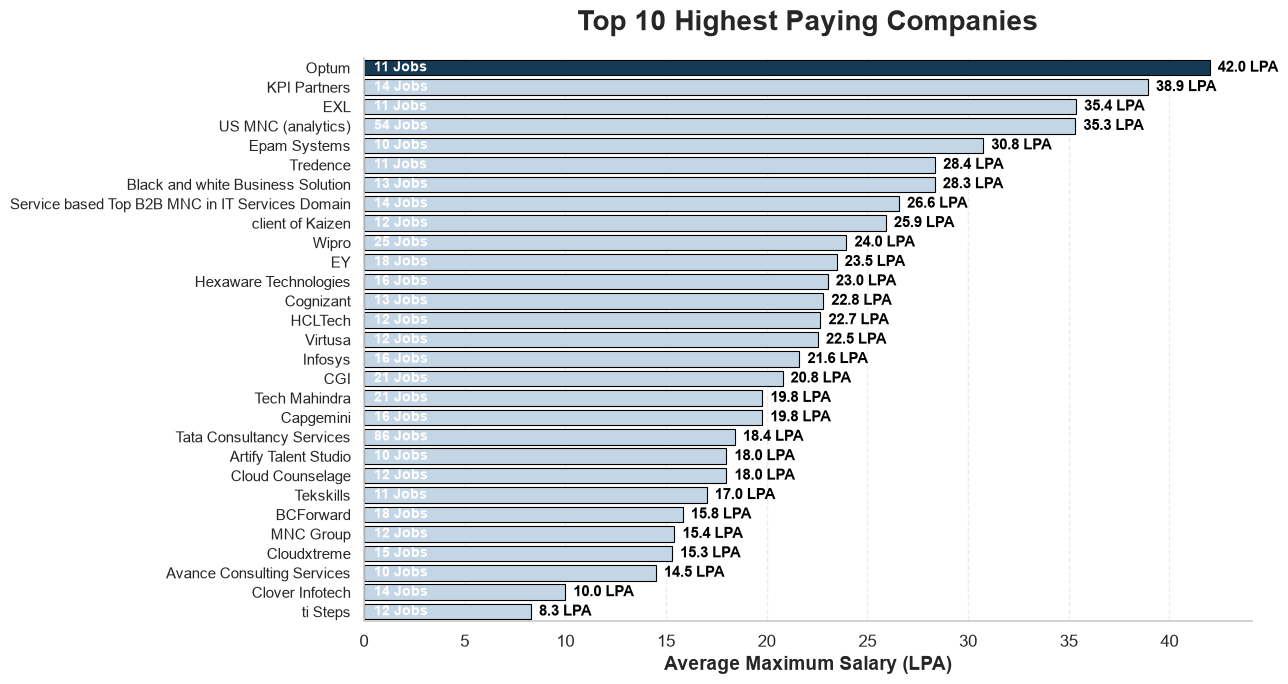

In [327]:
plt.figure(figsize=(13,7))

# Highlight the highest-paying company
colors = ["#0B3C5D"] + ["#BFD7EA"] * (len(company_salary)-1)

ax = sns.barplot(
    data=company_salary,
    x="Average_Salary",
    y="company_name",
    palette=colors,
    edgecolor="black",
    linewidth=0.8
)

# Add salary labels
for i, value in enumerate(company_salary["Average_Salary"]):
    ax.text(
        value + 0.4,
        i,
        f"{value:.1f} LPA",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# Add job count inside each bar
for i, row in enumerate(company_salary.itertuples()):
    ax.text(
        0.5,
        i,
        f"{row.Job_Count} Jobs",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

plt.title(
    "Top 10 Highest Paying Companies",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Average Maximum Salary (LPA)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("")

plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../Images/10_highest_paying_companies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The chart highlights the top 10 companies offering the highest average maximum salaries for technology jobs.
- Only companies with at least 10 salary records were included to improve the reliability of the analysis.
- The highest-paying company offers a significantly higher average salary compared to the remaining companies.
- Job count labels provide additional context, helping distinguish between consistently high-paying companies and those with fewer job postings.
- The analysis suggests that salary offerings vary considerably across organizations, making company selection an important factor for job seekers.

# 📊 Question 11: Most In-Demand Skills

## Business Question

Which technical skills are most frequently required in technology job postings?

## Objective

Identify the most in-demand technical skills by analyzing the frequency of skills mentioned across job postings.

## Why This Analysis?

Understanding skill demand helps job seekers prioritize learning the most valuable technologies. It also provides insights into current industry requirements and emerging technology trends.

In [328]:
df["skills_required"].head(10)

0    Computer science, Data analysis, data science,...
1    Basic, Data management, Business analytics, An...
2                                                  NaN
3                                                  NaN
4                                                  NaN
5                                                  NaN
6                                                  NaN
7    Supply chain, data science, Aerospace, Machine...
8    Product management, Prototype, data science, C...
9    python, data analysis, data domain, vertex, da...
Name: skills_required, dtype: str

In [329]:
df["skills_required"].sample(10, random_state=42)

259      Data analysis, Data modeling, Analytical, Cons...
21183    com, project management, media relations, docu...
20313    SAP PI, Sap Popi, SAP SD, Sap Pi Po, Pi / Po, ...
8541     Data analysis, Simulation, System integration,...
2004     Azure, PySpark, Azure Databricks, Azure Data F...
11167    O2C, Data analysis, SAP, Dispute resolution, E...
10821    Help Desk, Customer Service, data analysis, cu...
14675    Computer science, Backend, Linux, GCP, Artific...
21923    Embedded C, Multithreading, Data Sets, OOPS, P...
6428     Automation, devops, amazon redshift, Cloud, In...
Name: skills_required, dtype: str

In [330]:
df["skills_required"].isna().sum()

np.int64(547)

In [331]:
df["skills_required"].iloc[0]

'Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics'

In [332]:
df["skills_required"].iloc[10]

'Supply chain, Computer science, Business process, Data analysis, Machine learning, Network security, Data structures, Troubleshooting'

In [333]:
skills = (
    df["skills_required"]
    .dropna()
    .str.lower()
    .str.split(",")
)

In [334]:
from itertools import chain

all_skills = list(chain.from_iterable(skills))

# Remove extra spaces
all_skills = [skill.strip() for skill in all_skills]

len(all_skills)

176425

In [335]:
from collections import Counter

skill_counts = Counter(all_skills)

top_skills = (
    pd.DataFrame(
        skill_counts.items(),
        columns=["Skill", "Count"]
    )
    .sort_values(
        by="Count",
        ascending=False
    )
    .head(15)
)

top_skills

,Skill,Count
19,python,4266
1,data analysis,3776
12,machine learning,3520
49,sql,2940
11,analytical,2427
325,business analysis,2396
48,artificial intelligence,2137
39,automation,1995
0,computer science,1699
50,data,1654


In [336]:
remove_skills = [
    "data",
    "analytics",
    "analytical",
    "computer science",
    "business analysis",
    "business analyst",
    "project management",
    "management",
    "business",
    "analysis",
    "customer service",
    "communication",
    "consulting"
]

In [337]:
top_skills = top_skills[
    ~top_skills["Skill"].isin(remove_skills)
]

top_skills = top_skills.head(10)

top_skills

,Skill,Count
19,python,4266
1,data analysis,3776
12,machine learning,3520
49,sql,2940
48,artificial intelligence,2137
39,automation,1995
17,agile,1401
93,data engineering,1118


In [338]:
all_skills = [skill.strip() for skill in all_skills]

In [339]:
all_skills = [skill.strip().lower() for skill in all_skills]

remove_skills = [
    "data",
    "analytics",
    "analytical",
    "computer science",
    "business analysis",
    "business analyst",
    "project management",
    "management",
    "analysis",
    "business",
    "customer service",
    "consulting",
    "customer engagement"
]

all_skills = [
    skill
    for skill in all_skills
    if skill not in remove_skills
]

In [ ]:
import squarify

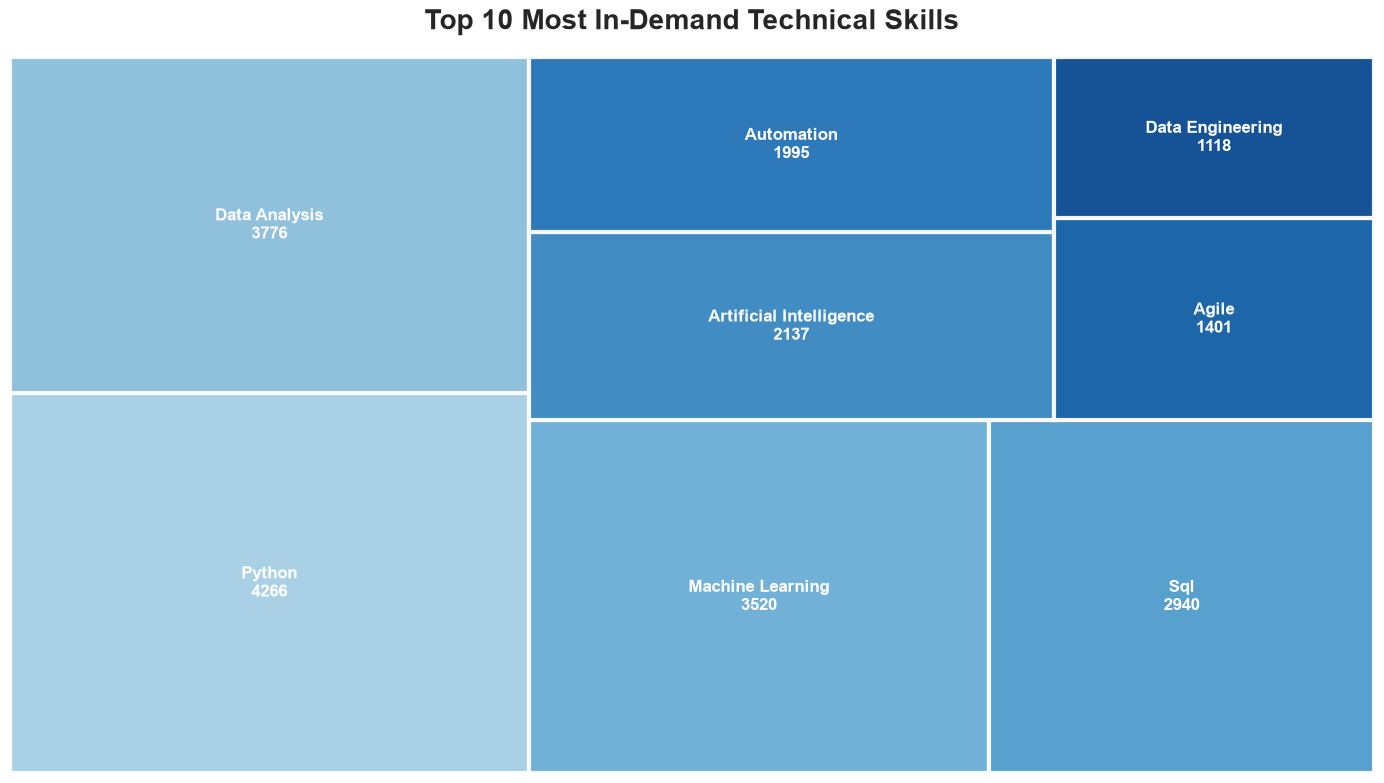

In [341]:
import matplotlib.cm as cm
import numpy as np

plt.figure(figsize=(14, 8))

# Create gradient colors
colors = cm.Blues(np.linspace(0.35, 0.9, len(top_skills)))

squarify.plot(
    sizes=top_skills["Count"],
    label=[
        f"{skill.title()}\n{count}"
        for skill, count in zip(
            top_skills["Skill"],
            top_skills["Count"]
        )
    ],
    color=colors,
    edgecolor="white",
    linewidth=3,
    alpha=0.95,
    text_kwargs={
        "fontsize":12,
        "fontweight":"bold",
        "color":"white"
    }
)

plt.title(
    "Top 10 Most In-Demand Technical Skills",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.axis("off")

plt.tight_layout()
plt.show()

### 📌 Observation

- Python emerged as the most in-demand technical skill across technology job postings.
- SQL, Machine Learning, Artificial Intelligence, and Automation are also highly sought-after, reflecting the growing demand for data-driven and AI-focused roles.
- The larger rectangles represent skills that appear more frequently in job postings, making it easy to identify the technologies that dominate the current job market.
- Professionals who develop expertise in these technologies are likely to have stronger employment opportunities in the technology sector.

# 📊 Question 12: Correlation Analysis

## Business Question

Which numerical variables are most strongly related to each other in technology job postings?

## Objective

Analyze the relationships between important numerical variables to identify patterns that may influence salary, experience requirements, company ratings, and job characteristics.

## Why This Analysis?

Correlation analysis helps identify whether changes in one variable are associated with changes in another. These insights help understand salary trends, hiring patterns, and the overall technology job market.

In [342]:
corr_data = df[[
    "salary_min_lpa",
    "salary_max_lpa",
    "salary_midpoint_lpa",
    "experience_min_yrs",
    "experience_max_yrs",
    "company_rating",
    "skills_count",
    "days_since_posted"
]]

In [343]:
corr_data = corr_data.rename(columns={
    "salary_min_lpa": "Min Salary",
    "salary_max_lpa": "Max Salary",
    "salary_midpoint_lpa": "Avg Salary",
    "experience_min_yrs": "Min Experience",
    "experience_max_yrs": "Max Experience",
    "company_rating": "Company Rating",
    "skills_count": "Skills Count",
    "days_since_posted": "Days Posted"
})

corr_matrix = corr_data.corr()

In [344]:
corr_data.isnull().sum()

Min Salary        0
Max Salary        0
Avg Salary        0
Min Experience    0
Max Experience    0
Company Rating    0
Skills Count      0
Days Posted       0
dtype: int64

In [345]:
corr_matrix = corr_data.corr()

corr_matrix

,Min Salary,Max Salary,Avg Salary,Min Experience,Max Experience,Company Rating,Skills Count,Days Posted
Min Salary,1.000000,0.968728,0.988430,0.135336,0.138712,-0.004251,-0.137173,-0.122237
Max Salary,0.968728,1.000000,0.995155,0.134462,0.145399,-0.004080,-0.164384,-0.125827
Avg Salary,0.988430,0.995155,1.000000,0.135823,0.143847,-0.004179,-0.154842,-0.125353
Min Experience,0.135336,0.134462,0.135823,1.000000,0.888029,0.011152,0.002173,-0.126857
Max Experience,0.138712,0.145399,0.143847,0.888029,1.000000,0.014177,0.001471,-0.124629
Company Rating,-0.004251,-0.004080,-0.004179,0.011152,0.014177,1.000000,-0.005820,-0.012198
Skills Count,-0.137173,-0.164384,-0.154842,0.002173,0.001471,-0.005820,1.000000,-0.157916
Days Posted,-0.122237,-0.125827,-0.125353,-0.126857,-0.124629,-0.012198,-0.157916,1.000000


In [ ]:


# Import Libraries
import os
import pandas as pd
import plotly.express as px
import plotly.io as pio



# ------------------------------------------
# Select Numerical Features
# ------------------------------------------

corr_df = df[
    [
        "salary_max_lpa",
        "experience_min_yrs",
        "experience_max_yrs",
        "company_rating",
        "skills_count",
        "days_since_posted"
    ]
].copy()

# ------------------------------------------
# Rename Columns
# ------------------------------------------

corr_df.columns = [
    "Max Salary",
    "Min Experience",
    "Max Experience",
    "Company Rating",
    "Skills Count",
    "Days Posted"
]

# ------------------------------------------
# Correlation Matrix
# ------------------------------------------

corr = corr_df.corr().round(2)

# ------------------------------------------
# Create Interactive Heatmap
# ------------------------------------------

fig = px.imshow(
    corr,

    text_auto=".2f",

    color_continuous_scale="RdBu_r",

    zmin=-1,
    zmax=1,

    aspect="auto"
)

# ------------------------------------------
# Professional Layout
# ------------------------------------------

fig.update_layout(

    title=dict(
        text="Correlation Between Key Job Features",
        x=0.5,
        font=dict(size=24)
    ),

    width=900,
    height=700,

    font=dict(
        family="Arial",
        size=16,
        color="black"
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",

    coloraxis_colorbar=dict(
        title="Correlation"
    )
)

# ------------------------------------------
# Axis Formatting
# ------------------------------------------

fig.update_xaxes(

    title="Features",

    tickangle=-35,

    showgrid=False,

    tickfont=dict(size=14)
)

fig.update_yaxes(

    title="Features",

    tickfont=dict(size=14),

    showgrid=False
)

# ------------------------------------------
# Show Figure
# ------------------------------------------

fig.show()

fig.write_html(
    os.path.join(
        OUTPUT_FOLDER,
        "q12_correlation_heatmap.html"
    )
)
# ------------------------------------------
# Save High Quality PNG
# ------------------------------------------
try:
    fig.write_image(
        os.path.join(
            OUTPUT_FOLDER,
            "q12_correlation_heatmap.png"
        ),
        scale=4
    )

    print("✅ PNG Saved Successfully")

except Exception as e:
    print("PNG could not be saved.")
    print(e)

print("✅ HTML Saved Successfully")

✅ PNG Saved Successfully
✅ HTML Saved Successfully


## Project Summary

This Exploratory Data Analysis (EDA) examined over 23,000 technology job postings to understand hiring patterns, salary trends, required skills, company characteristics, work modes, and geographical distribution of opportunities.

The analysis focused on identifying valuable insights that can help job seekers, recruiters, and organizations better understand the current technology job market.

## Key Findings

### 💼 Salary Insights
- Salary varies significantly across different job roles and cities.
- Experience plays an important role in determining salary levels.
- Some cities consistently offer higher average salaries than others.

### 📍 Location Insights
- Major metropolitan cities dominate technology hiring.
- Cities such as Bangalore, Hyderabad, Chennai, Pune, Mumbai, and Noida account for a large share of job opportunities.

### 🏢 Company Insights
- Large IT service companies contribute the highest number of job openings.
- Company ratings show only a weak relationship with offered salaries.

### 🧑‍💻 Skills Insights
- Python emerged as one of the most in-demand technical skills.
- Data Analysis, SQL, Machine Learning, Artificial Intelligence, and Business Analysis were frequently requested across job postings.

### 🌍 Work Mode Insights
- On-site jobs remain the dominant hiring model.
- Hybrid opportunities are growing, while fully remote jobs remain comparatively limited.



### For Job Seekers

- Develop strong skills in Python, SQL, Machine Learning, and Data Analysis.
- Focus on opportunities in major technology hubs where both salaries and job availability are higher.
- Gain practical experience through projects and internships to improve salary potential.

### For Recruiters

- Benchmark salaries against major technology hubs.
- Promote flexible work arrangements to attract skilled professionals.
- Clearly specify required technical skills within job descriptions.

### For Organizations

- Invest in upskilling programs for emerging technologies.
- Offer competitive compensation packages in high-demand domains.
- Monitor regional hiring trends to remain competitive in talent acquisition.

# Conclusion

This project provided a comprehensive analysis of the technology job market using Python, Pandas, NumPy, Matplotlib, Seaborn, and Plotly.

The insights generated from this analysis can support better career decisions for job seekers and assist organizations in understanding hiring trends, salary patterns, and skill demands.

The cleaned dataset and visualizations developed during this EDA will also serve as the foundation for the next phase of the project, where an interactive Streamlit dashboard will be built to enable dynamic exploration of these insights.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Jupyter Notebook